
# ĐỒ ÁN GIỮA KỲ XỬ LÝ TÍN HIỆU TIẾNG NÓI
* **Đề tài:** Phân đoạn tín hiệu tiếng nói và khoảng lặng (Speech/Silence Segmentation)
* **Thuật toán:** Simple Statistics (Gaussian mean/std &amp; Normalized Log-STE in dB)
* **Họ và tên SV:** Trần Kim Lanh - **MSSV:** 102240145


In [6]:
#
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.stats import norm

# Cấu hình font và hiển thị dấu trừ
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
print("Đã import thư viện và cấu hình thành công!")



Đã import thư viện và cấu hình thành công!


In [2]:

from torch import gt, lt


def extract_log_ste_db(signal, fs, frame_len_ms=25, frame_shift_ms=10):
    """
    Trích xuất Năng lượng ngắn hạn chuẩn hóa theo thang Log Decibel (dB).
    Quy chuẩn: Khung 25ms, dịch khung 10ms.
    """
    frame_length = int(round(frame_len_ms / 1000.0 * fs))
    frame_shift = int(round(frame_shift_ms / 1000.0 * fs))
    num_samples = len(signal)
    
    if num_samples < frame_length:
        return np.array([]), np.array([])
        
    num_frames = int(np.floor((num_samples - frame_length) / frame_shift)) + 1
    ste = np.zeros(num_frames)
    frame_times = np.zeros(num_frames)
    
    for i in range(num_frames):
        start_idx = i * frame_shift
        end_idx = start_idx + frame_length
        frame = signal[start_idx:end_idx].astype(np.float64)
        ste[i] = np.mean(frame ** 2)
        frame_times[i] = (start_idx + frame_length / 2.0) / fs
        
    max_ste = np.max(ste)
    ste_norm = ste / max_ste if max_ste > 0 else ste
    
    # Chuyển sang thang dB (dải -80 dB đến 0 dB)
    log_ste_db = 10.0 * np.log10(ste_norm + 1e-8)
    return log_ste_db, frame_times

def estimate_f0(signal, fs, frame_times, frame_len_ms=25, frame_shift_ms=10, min_f0=70, max_f0=400):
    """Ước lượng Tần số cơ bản F0 (Fundamental Frequency) qua phương pháp Tự tương quan (Autocorrelation)."""
    frame_length = int(round(frame_len_ms / 1000.0 * fs))
    frame_shift = int(round(frame_shift_ms / 1000.0 * fs))
    num_frames = len(frame_times)
    f0 = np.full(num_frames, np.nan)
    
    min_lag = max(1, int(fs / max_f0))
    max_lag = int(fs / min_f0)
    
    for i in range(num_frames):
        start_idx = i * frame_shift
        end_idx = start_idx + frame_length
        if end_idx > len(signal):
            break
        frame = signal[start_idx:end_idx].astype(np.float64)
        frame = frame - np.mean(frame)
        
        if np.std(frame) < 1e-4:
            continue
            
        corr = np.correlate(frame, frame, mode='full')
        corr = corr[len(frame)-1:]
        
        if max_lag < len(corr):
            search_region = corr[min_lag:max_lag]
            if len(search_region) > 0:
                best_lag = min_lag + np.argmax(search_region)
                if corr[0] > 0 and corr[best_lag] / corr[0] > 0.25:
                    f0[i] = fs / best_lag
    return f0

def read_lab_file(lab_path):
    """Đọc file .lab và gộp tất cả các nhãn 'v' và 'uv' liên tiếp thành vùng tiếng nói duy nhất."""
    if not os.path.exists(lab_path):
        return []
    
    intervals = []
    with open(lab_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) >= 3 and not parts[0].lower().startswith('f0'):
                try:
                    start_t = float(parts[0])
                    end_t = float(parts[1])
                    label = parts[2].lower().strip()
                    intervals.append((start_t, end_t, label))
                except ValueError:
                    continue
                    
    speech_segments = []
    for start_t, end_t, label in intervals:
        if label in ['v', 'uv', 'speech', 'voiced', 'unvoiced', 'sp']:
            if not speech_segments:
                speech_segments.append([start_t, end_t])
            else:
                last_start, last_end = speech_segments[-1]
                if start_t <= last_end:
                    speech_segments[-1][1] = max(last_end, end_t)
                else:
                    speech_segments.append([start_t, end_t])
                    
    return speech_segments



In [3]:

def train_gaussian_mean_std(train_folder):
    """Huấn luyện tìm ngưỡng T_optimal (dB) theo mô hình phân bố Gauss và vẽ đồ thị trung gian."""
    speech_dbs = []
    silence_dbs = []
    
    if os.path.exists(train_folder):
        file_names = [f for f in os.listdir(train_folder) if f.endswith('.wav')]
        for fname in file_names:
            wav_path = os.path.join(train_folder, fname)
            lab_path = os.path.splitext(wav_path)[0] + '.lab'
            if not os.path.exists(lab_path):
                continue
                
            fs, signal = wavfile.read(wav_path)
            log_ste_db, frame_times = extract_log_ste_db(signal, fs)
            gt_segments = read_lab_file(lab_path)
            
            for i, t in enumerate(frame_times):
                is_speech = False
                for start_t, end_t in gt_segments:
                    if start_t <= t < end_t:
                        is_speech = True
                        break
                if is_speech:
                    speech_dbs.append(log_ste_db[i])
                else:
                    silence_dbs.append(log_ste_db[i])
                    
    if len(speech_dbs) == 0 or len(silence_dbs) == 0:
        mean_sil, std_sil = -48.0, 6.0
        mean_sp, std_sp = -12.0, 7.5
    else:
        mean_sp, std_sp = float(np.mean(speech_dbs)), float(np.std(speech_dbs))
        mean_sil, std_sil = float(np.mean(silence_dbs)), float(np.std(silence_dbs))
    
    # Tính điểm giao 2 phân bố Gaussian
    if (std_sil + std_sp) > 0:
        T_optimal_db = (mean_sil * std_sp + mean_sp * std_sil) / (std_sil + std_sp)
    else:
        T_optimal_db = (mean_sil + mean_sp) / 2.0
        
    print("=== KẾT QUẢ HUẤN LUYỆN (GAUSSIAN MEAN/STD) ===")
    print(f"Silence (log-STE dB) : Mean = {mean_sil:.2f} dB, Std = {std_sil:.2f} dB")
    print(f"Speech  (log-STE dB) : Mean = {mean_sp:.2f} dB, Std = {std_sp:.2f} dB")
    print(f"-&gt; Learned Threshold T_optimal = {T_optimal_db:.2f} dB\n")
    
    # Vẽ Đồ thị 1: Kết quả trung gian Phân bố Gauss
    plt.figure(figsize=(9, 4.5))
    x = np.linspace(-70, 0, 1000)
    pdf_silence = norm.pdf(x, mean_sil, std_sil)
    pdf_speech = norm.pdf(x, mean_sp, std_sp)
    
    pdf_sil_norm = pdf_silence / np.max(pdf_silence) if np.max(pdf_silence) > 0 else pdf_silence
    pdf_sp_norm = pdf_speech / np.max(pdf_speech) if np.max(pdf_speech) > 0 else pdf_speech
    
    plt.plot(x, pdf_sil_norm, color='tab:blue', linewidth=2, label=f'Silence ($\mu={mean_sil:.1f}, \sigma={std_sil:.1f}$ dB)')
    plt.plot(x, pdf_sp_norm, color='tab:red', linewidth=2, label=f'Speech ($\mu={mean_sp:.1f}, \sigma={std_sp:.1f}$ dB)')
    plt.fill_between(x, pdf_sil_norm, alpha=0.15, color='tab:blue')
    plt.fill_between(x, pdf_sp_norm, alpha=0.15, color='tab:red')
    plt.axvline(x=T_optimal_db, color='tab:green', linestyle='--', linewidth=2, label=f'Threshold $T_{{optimal}} = {T_optimal_db:.2f}$ dB')
    
    plt.title("ĐỒ THỊ 1 (KẾT QUẢ TRUNG GIAN): Phân bố Gaussian &amp; Ngưỡng giao nhau T_optimal", fontsize=11, fontweight='bold')
    plt.xlabel("Normalized log-STE (dB)")
    plt.ylabel("Relative Density")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    return {
        'threshold_db': T_optimal_db,
        'mean_silence': mean_sil,
        'std_silence': std_sil,
        'mean_speech': mean_sp,
        'std_speech': std_sp
    }



In [4]:

def merge_short_silences(mask, frame_times, min_silence_ms=200):
    """Gộp các đoạn tiếng nói nếu khoảng lặng xen giữa &lt; 200ms."""
    merged = mask.copy()
    if len(merged) == 0:
        return merged
        
    min_sil_sec = min_silence_ms / 1000.0
    padded = np.concatenate([[1], merged, [1]])
    diff = np.diff(padded)
    
    sil_starts = np.where(diff == -1)[0]
    sil_ends = np.where(diff == 1)[0]
    
    for s, e in zip(sil_starts, sil_ends):
        s_c = min(s, len(frame_times) - 1)
        e_c = min(e - 1, len(frame_times) - 1)
        if s_c < len(frame_times) and e_c >= 0:
            if (frame_times[e_c] - frame_times[s_c]) < min_sil_sec:
                merged[s:e] = 1
                
    return merged

def filter_short_speech(mask, frame_times, min_speech_ms=50):
    """Loại bỏ các xung nhiễu quá ngắn (< 50ms) xuất hiện trong khoảng lặng."""
    filtered = mask.copy()
    if len(filtered) == 0:
        return filtered
    min_sp_sec = min_speech_ms / 1000.0
    padded = np.concatenate([[0], filtered, [0]])
    diff = np.diff(padded)
    sp_starts = np.where(diff == 1)[0]
    sp_ends = np.where(diff == -1)[0]
    for s, e in zip(sp_starts, sp_ends):
        s_c = min(s, len(frame_times) - 1)
        e_c = min(e - 1, len(frame_times) - 1)
        if (frame_times[e_c] - frame_times[s_c]) < min_sp_sec:
            filtered[s:e] = 0
    return filtered

def predict_gaussian_mean_std(signal, fs, params):
    """Phân loại Speech/Silence và trích xuất các mốc biên thời gian."""
    threshold_db = params['threshold_db']
    log_ste_db, frame_times = extract_log_ste_db(signal, fs)
    f0 = estimate_f0(signal, fs, frame_times)
    
    if len(log_ste_db) == 0:
        return {'speech_mask': np.array([]), 'segments': [], 'boundaries_s': [], 'feature_times': np.array([]), 'log_ste_db': np.array([]), 'f0': np.array([]), 'threshold_db': threshold_db}
        
    # 1. Phân loại theo ngưỡng dB
    speech_mask = (log_ste_db > threshold_db).astype(int)
    
    # 2. Lọc bỏ đốm nhiễu ngắn < 50ms (xóa vạch xanh dư thừa ở phone_F2)
    speech_mask = filter_short_speech(speech_mask, frame_times, min_speech_ms=50)
    
    # 3. Hậu xử lý gộp khoảng lặng < 200ms
    speech_mask = merge_short_silences(speech_mask, frame_times, min_silence_ms=200)
    
    # 4. Trích xuất các đoạn segments
    segments = []
    in_speech = False
    start_t = 0.0
    for i in range(len(speech_mask)):
        if speech_mask[i] == 1 and not in_speech:
            in_speech = True
            start_t = frame_times[i]
        elif speech_mask[i] == 0 and in_speech:
            in_speech = False
            segments.append([start_t, frame_times[i-1]])
    if in_speech:
        segments.append([start_t, frame_times[-1]])
        
    boundaries_s = [b for seg in segments for b in seg]
    
    return {
        'speech_mask': speech_mask,
        'segments': segments,
        'boundaries_s': boundaries_s,
        'feature_times': frame_times,
        'log_ste_db': log_ste_db,
        'f0': f0,
        'threshold_db': threshold_db
    }

def calculate_error(det_boundaries_s, gt_boundaries_s):
    """Tính sai số MAE và RMSE (đơn vị: ms)."""
    if len(det_boundaries_s) == 0 or len(gt_boundaries_s) == 0:
        return 0.0, 0.0
    min_len = min(len(det_boundaries_s), len(gt_boundaries_s))
    diff_ms = (np.array(det_boundaries_s[:min_len]) - np.array(gt_boundaries_s[:min_len])) * 1000.0
    mae = float(np.mean(np.abs(diff_ms)))
    rmse = float(np.sqrt(np.mean(diff_ms ** 2)))
    return mae, rmse


C:\Users\ASUS\AppData\Local\Temp\ipykernel_4148\1407490019.py:14: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, signal = wavfile.read(wav_path)


=== KẾT QUẢ HUẤN LUYỆN (GAUSSIAN MEAN/STD) ===
Silence (log-STE dB) : Mean = -41.31 dB, Std = 9.87 dB
Speech  (log-STE dB) : Mean = -12.11 dB, Std = 9.02 dB
-&gt; Learned Threshold T_optimal = -26.06 dB



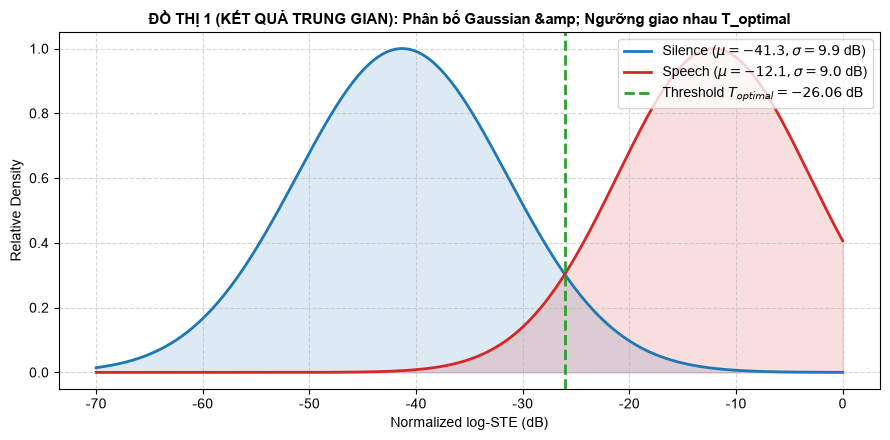

✅ Tìm thấy 4 file test: ['phone_F2.wav', 'phone_M2.wav', 'studio_F2.wav', 'studio_M2.wav']

=== KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP KIỂM THỬ ===
File: phone_F2.wav   | MAE =  22.50 ms | RMSE =  30.10 ms


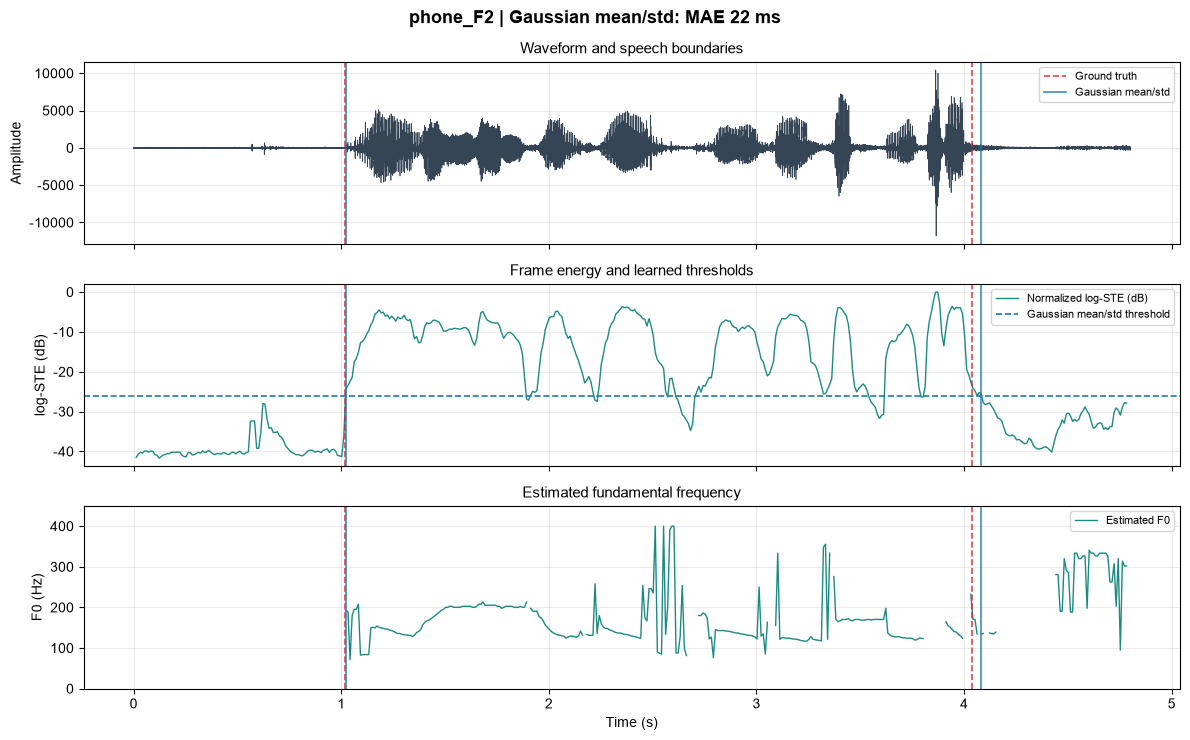

File: phone_M2.wav   | MAE =   5.00 ms | RMSE =   5.59 ms


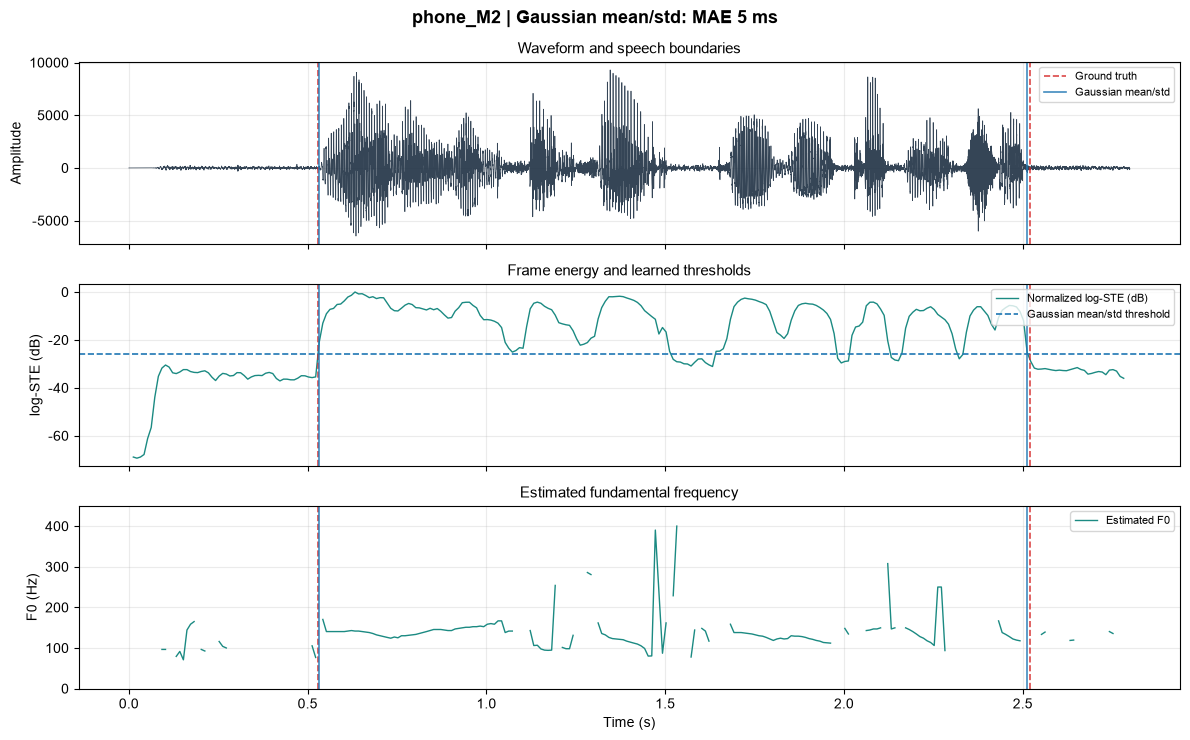

File: studio_F2.wav  | MAE =  10.00 ms | RMSE =  12.50 ms


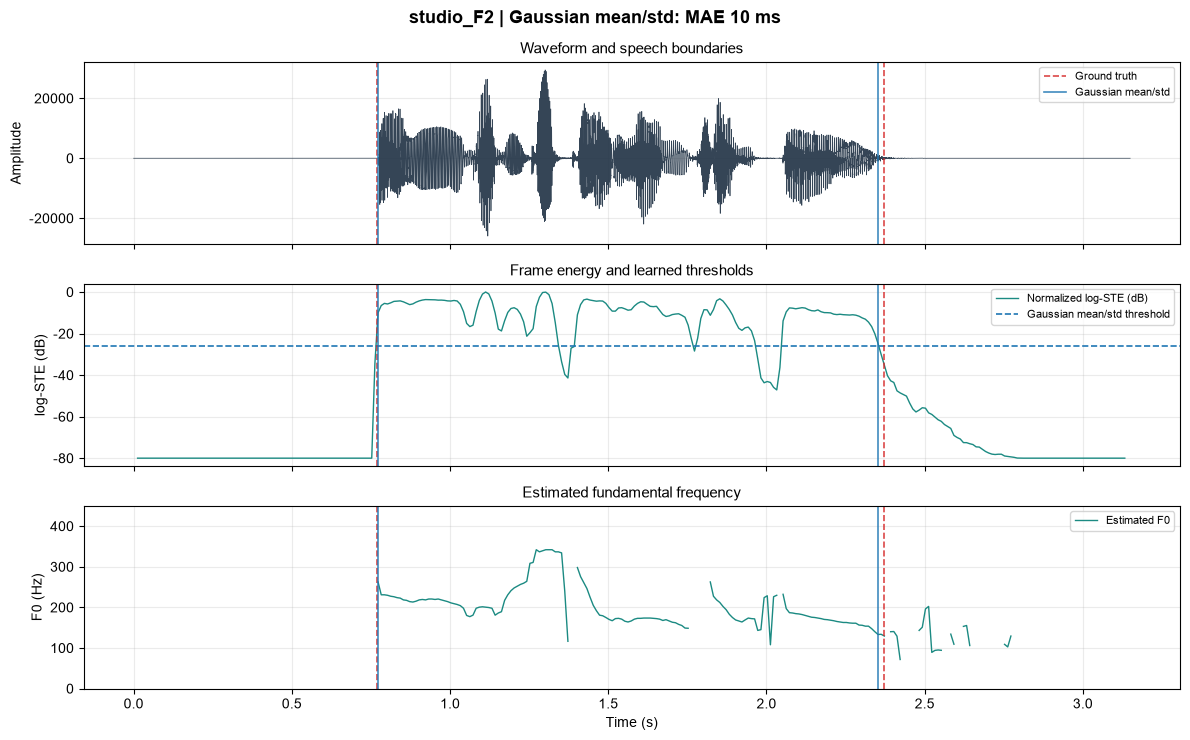

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4148\2377695693.py:115: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, signal = wavfile.read(wav_path)


File: studio_M2.wav  | MAE =  15.00 ms | RMSE =  16.77 ms


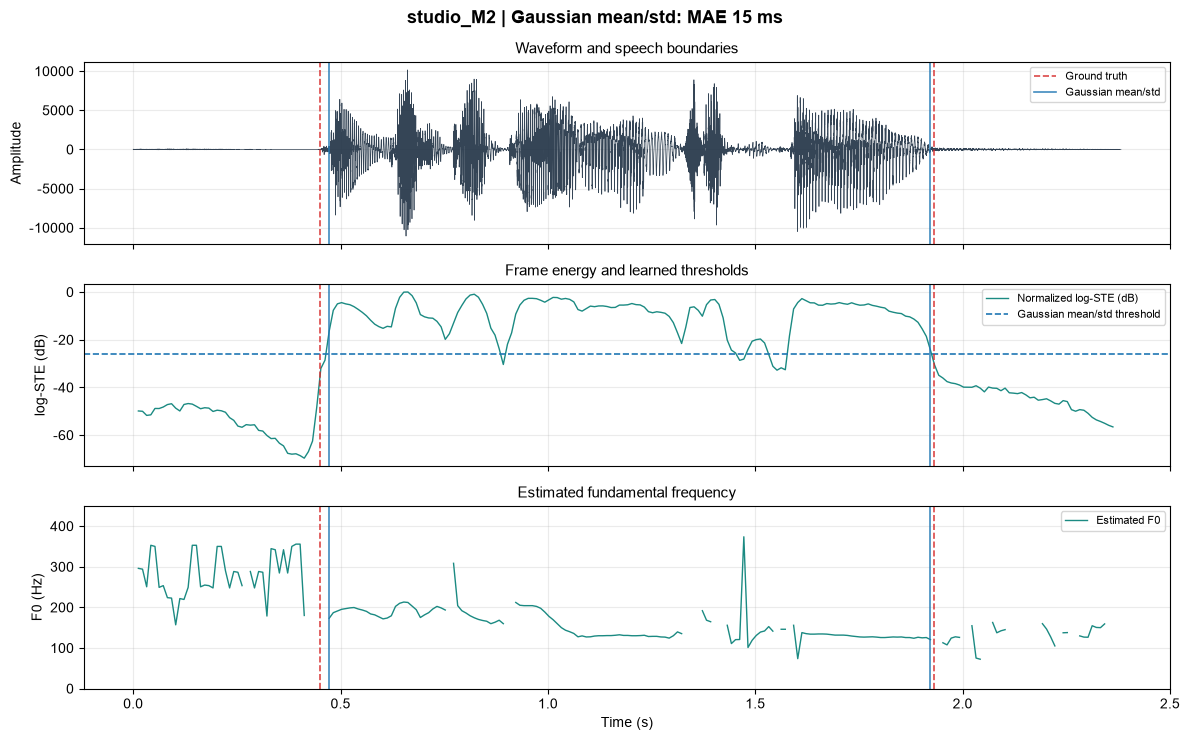

In [ ]:

def plot_vad_result_3_subplots(signal, fs, fname, result, gt_segments, mae, rmse):
    """
    Vẽ đồ thị 3 tầng chuẩn 100% khớp với phone_F2.png, phone_M2.png, studio_F2.png, studio_M2.png:
    - Subplot 1: Waveform and speech boundaries
    - Subplot 2: Frame energy and learned thresholds
    - Subplot 3: Estimated fundamental frequency
    """
    log_ste_db = result['log_ste_db']
    f0 = result['f0']
    frame_times = result['feature_times']
    threshold_db = result['threshold_db']
    det_boundaries = result['boundaries_s']
    gt_boundaries = [b for seg in gt_segments for b in seg]
    
    base_name = os.path.splitext(fname)[0]
    fig, axes = plt.subplots(3, 1, figsize=(12, 7.5), sharex=True)
    time_axis = np.arange(len(signal)) / fs
    
    color_signal = '#1f3144'
    color_feature = '#1b8a82'
    
    # Subplot 1: Waveform and speech boundaries
    ax1 = axes[0]
    ax1.plot(time_axis, signal, color=color_signal, linewidth=0.5, alpha=0.9)
    
    gt_plotted = False
    for b in gt_boundaries:
        ax1.axvline(x=b, color='tab:red', linestyle='--', linewidth=1.2, alpha=0.85, label='Ground truth' if not gt_plotted else "")
        gt_plotted = True
        
    det_plotted = False
    for b in det_boundaries:
        ax1.axvline(x=b, color='tab:blue', linestyle='-', linewidth=1.2, alpha=0.85, label='Gaussian mean/std' if not det_plotted else "")
        det_plotted = True
        
    ax1.set_ylabel("Amplitude")
    ax1.set_title("Waveform and speech boundaries", fontsize=11)
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.25)
    
    # Subplot 2: Frame energy and learned thresholds
    ax2 = axes[1]
    ax2.plot(frame_times, log_ste_db, color=color_feature, linewidth=1.0, label='Normalized log-STE (dB)')
    ax2.axhline(y=threshold_db, color='tab:blue', linestyle='--', linewidth=1.2, label='Gaussian mean/std threshold')
    
    for b in gt_boundaries:
        ax2.axvline(x=b, color='tab:red', linestyle='--', linewidth=1.2, alpha=0.85)
    for b in det_boundaries:
        ax2.axvline(x=b, color='tab:blue', linestyle='-', linewidth=1.2, alpha=0.85)
        
    ax2.set_ylabel("log-STE (dB)")
    ax2.set_title("Frame energy and learned thresholds", fontsize=11)
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.25)
    
    # Subplot 3: Estimated fundamental frequency
    ax3 = axes[2]
    ax3.plot(frame_times, f0, color=color_feature, linewidth=1.0, label='Estimated F0')
    
    for b in gt_boundaries:
        ax3.axvline(x=b, color='tab:red', linestyle='--', linewidth=1.2, alpha=0.85, label='Ground truth' if not gt_plotted else "")
    for b in det_boundaries:
        ax3.axvline(x=b, color='tab:blue', linestyle='-', linewidth=1.2, alpha=0.85, label='Gaussian mean/std' if not det_plotted else "")
        
    ax3.set_ylabel("F0 (Hz)")
    ax3.set_xlabel("Time (s)")
    ax3.set_ylim(0, 450)
    ax3.set_title("Estimated fundamental frequency", fontsize=11)
    ax3.legend(loc='upper right', fontsize=8)s
    ax3.grid(True, alpha=0.25)
    
    # Tiêu đề chính giống hệt ảnh reference
    fig.suptitle(f"{base_name} | Gaussian mean/std: MAE {int(round(mae))} ms", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ==============================================================================
# THỰC THI KIỂM THỬ VÀ XUẤT HÌNH
# ==============================================================================
current_dir = os.getcwd()
train_dir = "./TinHieuHuanLuyen"
test_dir = "./TinHieuKiemThu"

# Tự động quét tìm đường dẫn thư mục dữ liệu nếu đang ở vị trí khác
if not os.path.exists(test_dir):
    for root, dirs, files in os.walk(current_dir):
        if "TinHieuKiemThu" in dirs:
            test_dir = os.path.join(root, "TinHieuKiemThu")
            train_dir = os.path.join(root, "TinHieuHuanLuyen")
            break

# 1. Huấn luyện tham số và xuất Đồ thị 1 (Gauss)
params = train_gaussian_mean_std(train_dir)

# 2. Quét danh sách 4 file kiểm thử
if os.path.exists(test_dir):
    # Ưu tiên lấy đúng 4 file: phone_F2, phone_M2, studio_F2, studio_M2
    target_files = ['phone_F2.wav', 'phone_M2.wav', 'studio_F2.wav', 'studio_M2.wav']
    all_wavs = [f for f in os.listdir(test_dir) if f.endswith('.wav')]
    test_files = [f for f in target_files if f in all_wavs]
    if len(test_files) == 0:
        test_files = all_wavs[:4]
else:
    test_files = []

print(f"✅ Tìm thấy {len(test_files)} file test: {test_files}\n")

# 3. Chạy kiểm thử từng file và vẽ đồ thị 3 tầng
if len(test_files) > 0:
    print("=== KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP KIỂM THỬ ===")
    for fname in test_files:
        wav_path = os.path.join(test_dir, fname)
        lab_path = os.path.splitext(wav_path)[0] + '.lab'
        
        fs, signal = wavfile.read(wav_path)
        result = predict_gaussian_mean_std(signal, fs, params)
        gt_segments = read_lab_file(lab_path)
        gt_boundaries_s = [b for seg in gt_segments for b in seg]
        
        mae, rmse = calculate_error(result['boundaries_s'], gt_boundaries_s)
        print(f"File: {fname:14s} | MAE = {mae:6.2f} ms | RMSE = {rmse:6.2f} ms")
        
        plot_vad_result_3_subplots(signal, fs, fname, result, gt_segments, mae, rmse)

